## $\color{red}{\text{ANALYSIS of M2.0-class flare}}$

---

#### CONTINUATION: we analyze M2.0-class solar flare (occured on $15/10/2024$ around $18:30\,\rm UT$),

#### which was observed during the Solar Orbiter Major Flare Watch Campaign.

In [1]:
# we import the necessary modules

# standard libraries
import os
import glob
import warnings
from datetime import datetime

# numerical & data handling
import numpy as np
import pandas as pd

# signal & interpolation
from scipy.stats import pearsonr
from scipy.signal import find_peaks, savgol_filter, butter, filtfilt
from scipy.interpolate import LSQUnivariateSpline
from scipy.ndimage import label as nd_label
from scipy.ndimage import center_of_mass
from numba import jit
import pywt

# astropy
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.timeseries import LombScargle

# sunpy
import sunpy.map
from sunpy.net import Fido, attrs as a
from sunpy.map import Map
from sunpy.timeseries import TimeSeries

# stixpy
from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook
from stixpy.product import Product
from stixpy.timeseries.quicklook import QLLightCurve

# sunpy-soar
import sunpy_soar

# plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as pltc
from matplotlib.patches import Rectangle, Circle
import matplotlib.animation as animation
from matplotlib.lines import Line2D

# wavelet
from waveletFunctions import wavelet, wave_signif
import waveletFunctions as wf

warnings.filterwarnings("ignore")

### $\color{red}{\text{1. Spacecraft positions at the time of event}} $

---

#### Here, we plot spacecraft positions in order to deal with viewing angle and time correction.

#### - we're not sure if the event position is plotted correctly!

Solar Orbiter distance: 0.43 AU
Earth distance: 1.00 AU
Viewing angle difference: 31.2°


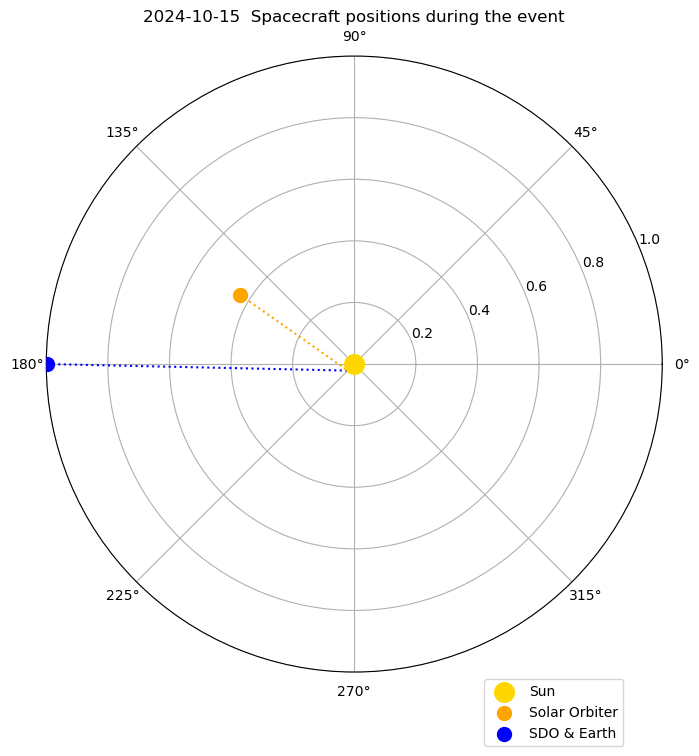

In [2]:
def spacecraft_positions(positions, flare_time='2024-10-15 18:30:00'):
    positions = pd.read_csv(positions)
    positions['UTC'] = pd.to_datetime(positions['UTC (no light time correction)']).dt.tz_localize(None)
    
    flare_idx = np.argmin(np.abs(positions['UTC'] - pd.Timestamp(flare_time)))
    
    solo_pos = np.array([positions.iloc[flare_idx]['SolO_X (au)'], 
                        positions.iloc[flare_idx]['SolO_Y(au)'], 
                        positions.iloc[flare_idx]['SolO_Z(au)']])
    
    earth_pos = np.array([positions.iloc[flare_idx]['earth_X(AU)'], 
                         positions.iloc[flare_idx]['earth_Y(AU)'], 
                         positions.iloc[flare_idx]['earth_Z(AU)']])
    
    dot_product = np.dot(solo_pos, earth_pos)
    solo_mag = np.linalg.norm(solo_pos)
    earth_mag = np.linalg.norm(earth_pos)
    angle_rad = np.arccos(np.clip(dot_product / (solo_mag * earth_mag), -1, 1))
    angle_deg = np.degrees(angle_rad)
    
    solo_r = solo_mag
    solo_theta = np.arctan2(solo_pos[1], solo_pos[0])
    earth_r = earth_mag
    earth_theta = np.arctan2(earth_pos[1], earth_pos[0])
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    ax.set_ylim(0, 1.0)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    
    ax.scatter(0, 0, s=200, c='gold', marker='o', label='Sun', zorder=10)
    ax.scatter(solo_theta, solo_r, s=100, c='orange', marker='o', label='Solar Orbiter', zorder=5)
    ax.scatter(earth_theta, earth_r, s=100, c='blue', marker='o', label='SDO & Earth', zorder=5)
    
    event_theta = np.radians(-135)  
    event_r = 0.03
    # ax.scatter(event_theta, event_r, s=150, c='red', marker='*', label='event location', zorder=15)
    
    ax.plot([solo_theta, event_theta], [solo_r, event_r], 'orange', linestyle=':')
    ax.plot([earth_theta, event_theta], [earth_r, event_r], 'blue', linestyle=':')
    
    ax.set_title(f'{flare_time[:10]}  Spacecraft positions during the event')
    ax.legend(loc='upper left', bbox_to_anchor=(0.7, 0))
    ax.set_thetagrids(range(0, 360, 45), [f'{i}°' for i in range(0, 360, 45)])
    
    print(f'Solar Orbiter distance: {solo_r:.2f} AU')
    print(f'Earth distance: {earth_r:.2f} AU') 
    print(f'Viewing angle difference: {angle_deg:.1f}°')
    
    return fig, ax, angle_deg

fig, ax, angle = spacecraft_positions('stix.csv')
plt.show()

### $\color{red}{\text{2. STIX and GOES light curves}} $

---

#### We examine STIX light curves across multiple energy bands and compare those to 

#### light curves from GOES. We apply time correction here.

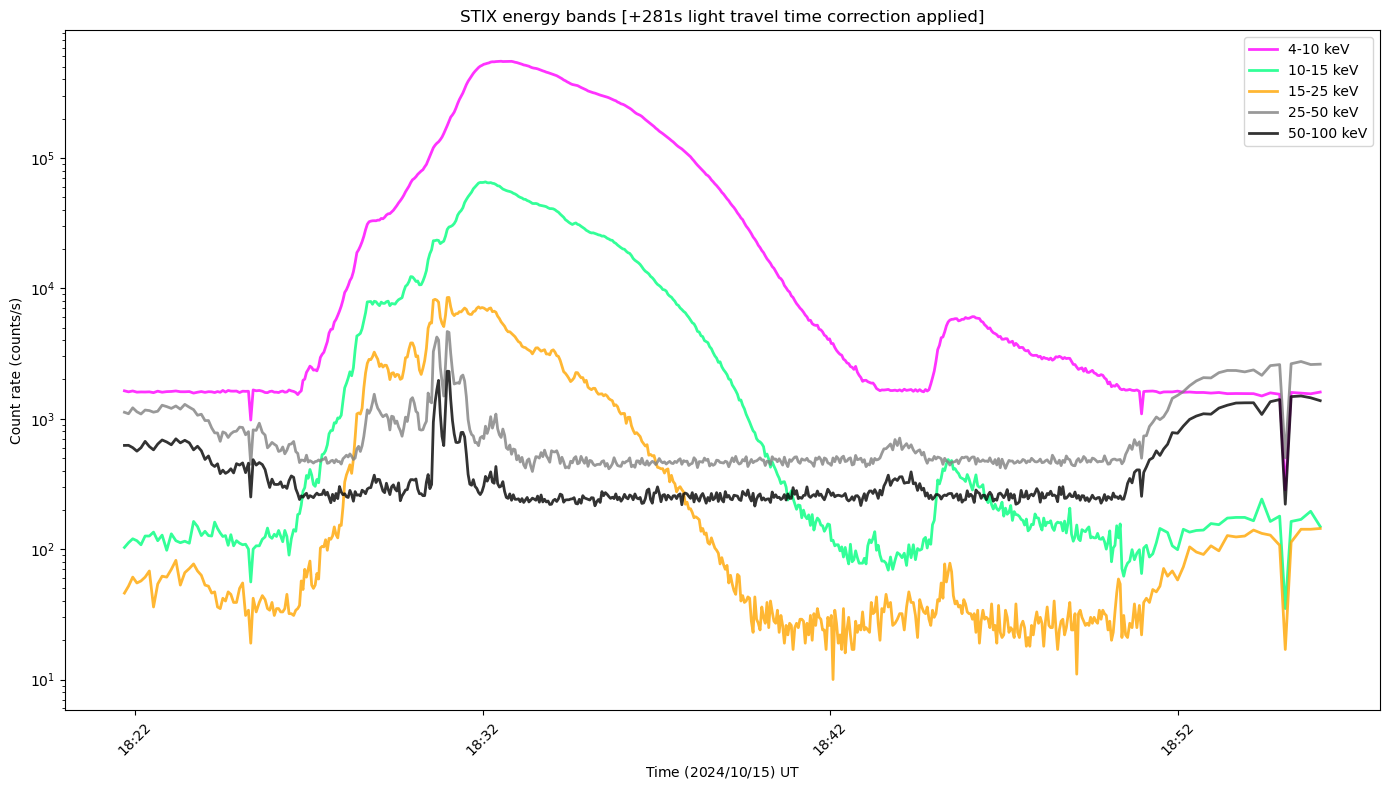

In [3]:
df = pd.read_csv('raw_light_curves.csv')
df['UTC'] = pd.to_datetime(df['UTC']) + pd.Timedelta(seconds=281)
df.set_index('UTC', inplace=True)
df = df.dropna()

energy_bands = {
    '4-10 keV': ['4 –⁠ 5 keV - Counts', '5 –⁠ 6 keV - Counts', '6 –⁠ 7 keV - Counts',
                 '7 –⁠ 8 keV - Counts', '8 –⁠ 9 keV - Counts', '9 –⁠ 10 keV - Counts'],
    '10-15 keV': ['10 –⁠ 11 keV - Counts', '11 –⁠ 12 keV - Counts', '12 –⁠ 13 keV - Counts', 
                  '13 –⁠ 14 keV - Counts', '14 –⁠ 15 keV - Counts'],
    '15-25 keV': ['15 –⁠ 16 keV - Counts', '16 –⁠ 18 keV - Counts', '18 –⁠ 20 keV - Counts',
                  '20 –⁠ 22 keV - Counts', '22 - 25 keV - Counts'],
    '25-50 keV': ['25 –⁠ 28 keV - Counts', '28 –⁠ 32 keV - Counts', '32 –⁠ 36 keV - Counts', 
                  '36 –⁠ 40 keV - Counts', '40 –⁠ 45 keV - Counts', '45 - 50 keV - Counts'],
    '50-100 keV': ['50 –⁠ 56 keV - Counts', '56 –⁠ 63 keV - Counts',
                   '63 –⁠ 70 keV - Counts', '70 –⁠ 76 keV - Counts', '76 –⁠ 84 keV - Counts',
                   '84 –⁠ 100 keV - Counts']}

stix_bands = {band: df[[col for col in cols if col in df.columns]].sum(axis=1) 
              for band, cols in energy_bands.items()}

stix_df = pd.DataFrame(stix_bands)
stix_df = stix_df.sort_index()

time_diff = stix_df.index.to_series().diff()
large_gaps = time_diff > pd.Timedelta(minutes=5)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['magenta', 'springgreen', 'orange', 'grey', 'black']

for band, color in zip(stix_df.columns, colors):
    data = stix_df[band].copy()
    data[large_gaps] = np.nan
    ax.plot(stix_df.index, data, label=band, color=color, 
            linewidth=2, alpha=0.8, linestyle='-', marker=None)

ax.set_yscale('log')
ax.set_xlabel(r'Time $(2024/10/15)$ UT')
ax.set_ylabel('Count rate (counts/s)')
ax.set_title('STIX energy bands [+281s light travel time correction applied]')
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
res = Fido.search(a.Time("2024-10-15T18:00:00", "2024-10-15T19:00:00"), a.Instrument('XRS'))

In [5]:
files = Fido.fetch(res)
goes = TimeSeries(files)

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

In [6]:
goes_data = goes[0].to_dataframe() 
goes_flare = goes_data.truncate("2024-10-15T18:22:00", "2024-10-15T18:55:00")

stix_4_10 = stix_df['4-10 keV']
stix_10_15 = stix_df['10-15 keV']
stix_15_25 = stix_df['15-25 keV']
stix_25_50 = stix_df['25-50 keV']
stix_50_100 = stix_df['50-100 keV']

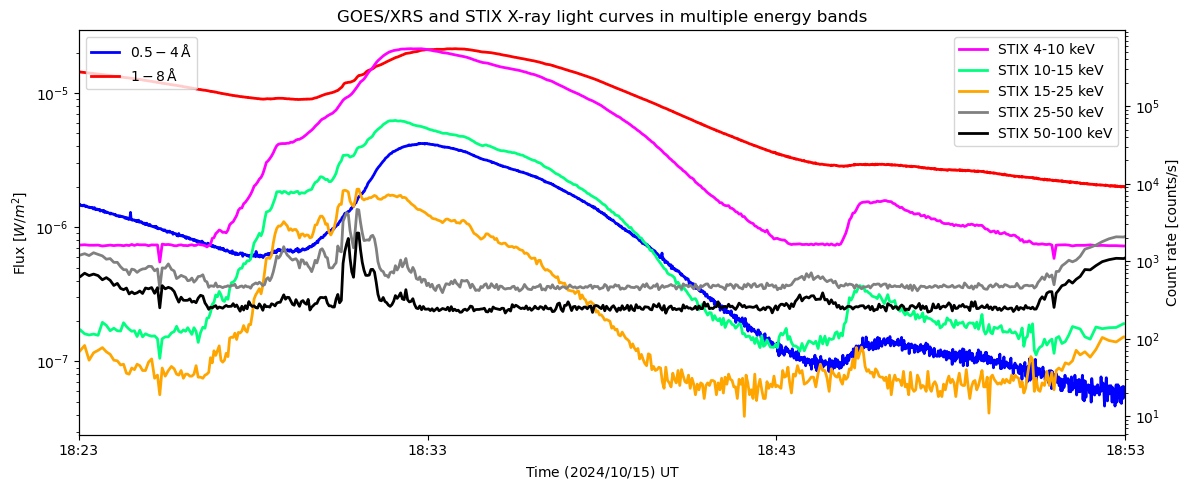

In [7]:
plt.figure(figsize=(12,5))

ax1 = plt.gca()
ax1.plot(goes_flare.index, goes_flare['xrsa'], color='blue', label=r'$0.5-4\,\rm\AA$', linewidth=2)
ax1.plot(goes_flare.index, goes_flare['xrsb'], color='red', label=r'$1-8\,\rm\AA$', linewidth=2)
ax1.set_ylabel('Flux $[W/m^2]$')
ax1.set_yscale('log')

ax2 = ax1.twinx()
 
ax2.plot(stix_4_10.index, stix_4_10, color='magenta', label='STIX 4-10 keV', linewidth=2)  
ax2.plot(stix_10_15.index, stix_10_15, color='springgreen', label='STIX 10-15 keV', linewidth=2)  
ax2.plot(stix_15_25.index, stix_15_25, color='orange', label='STIX 15-25 keV', linewidth=2) 
ax2.plot(stix_25_50.index, stix_25_50, color='gray', label='STIX 25-50 keV', linewidth=2)  
ax2.plot(stix_50_100.index, stix_50_100, color='black', label='STIX 50-100 keV', linewidth=2)  

ax2.set_yscale('log')
ax2.set_ylabel('Count rate [counts/s]')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
ax1.set_xlabel(r'Time $(2024/10/15)$ UT')
ax1.set_xlim("2024-10-15T18:23:00", "2024-10-15T18:53:00")

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('GOES/XRS and STIX X-ray light curves in multiple energy bands')
plt.tight_layout()
plt.show()

### $\color{red}{\text{3. STIX and Fermi GBM}} $

---

#### We compare specific STIX light curve to the one obtained from Fermi GBM.

In [8]:
res = Fido.search(a.Time("2024-10-15T18:00", "2024-10-15T19:00"), a.Instrument('GBM'), a.Source('FERMI'), a.Detector('N5'), a.Physobs('flux'))

In [9]:
files = Fido.fetch(res)
gbm = TimeSeries(files, concatenate=True)
gbm = gbm.to_dataframe().truncate("2024-10-15T18:20:00","2024-10-15T18:55:00")

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

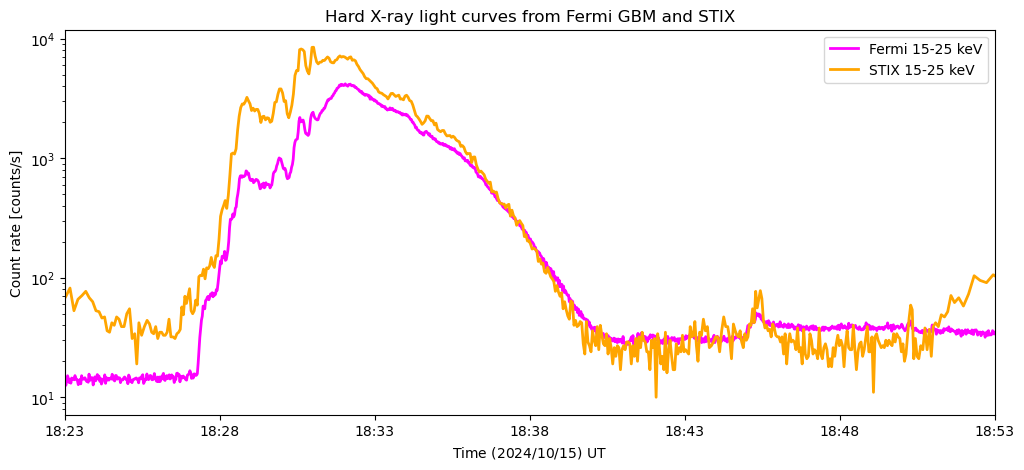

In [10]:
gbm_15_25 = gbm['15-25 keV'].resample('1600ms').mean().dropna() # resampling

plt.figure(figsize=(12,5))

plt.plot(gbm_15_25.index, gbm_15_25, color='magenta', label='Fermi 15-25 keV', linewidth=2)
plt.plot(stix_15_25.index, stix_15_25, color='orange', label='STIX 15-25 keV', linewidth=2) 

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.yscale('log')
plt.xlim("2024-10-15T18:23:00", "2024-10-15T18:53:00")
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Count rate [counts/s]')
plt.title(r'Hard X-ray light curves from Fermi GBM and STIX')
plt.legend()
plt.show()

### $\color{red}{\text{4. EUI/HRI (the high resolution EUV imager)}} $

---

#### We analyze the map during the *flare maximum* and we extract light curves from 

#### various kernels we find worth analysing.

In [11]:
p = '/home/zorzeus/sunpy/data'
files_eui = sorted(glob.glob(f'{p}/solo_L2_eui-hrieuv174*.fits'))
print(len(files_eui))

676


In [ ]:
base_map = Map(files_eui[20])  
flare_start_idx = 100
flare_end_idx = 350   

print(f"Creating base difference from {len(files_eui[flare_start_idx:flare_end_idx])} images...")

current_map = Map(files_eui[flare_start_idx])
max_diff_data = current_map.data - base_map.data

for i, file in enumerate(files_eui[flare_start_idx+1:flare_end_idx]):
    if i % 100 == 0: 
        print(f"Processing image {i+1}/{flare_end_idx-flare_start_idx}")
    current_map = Map(file)
    diff_data = current_map.data - base_map.data
    max_diff_data = np.maximum(max_diff_data, diff_data)

m1 = Map(max_diff_data, current_map.meta)

bl1= SkyCoord(1950*u.arcsec, -350*u.arcsec, frame=m1.coordinate_frame)
tr1 = SkyCoord(2150*u.arcsec, -200*u.arcsec, frame=m1.coordinate_frame)
sm1 = m1.submap(bottom_left=bl1, top_right=tr1)
levels = [25, 50, 75] * u.percent

fig = plt.figure(figsize=(12,8))
ax1 = plt.subplot(111, projection=sm1)  
sm1.plot(axes=ax1 ,cmap='viridis', norm=pltc.LogNorm(), clip_interval=(5, 99.9)*u.percent)
cbar = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', pad=0.02)

kernels = [SkyCoord(2020*u.arcsec, -260*u.arcsec, frame=sm1.coordinate_frame),
           SkyCoord(2025*u.arcsec, -320*u.arcsec, frame=sm1.coordinate_frame),
           SkyCoord(2030*u.arcsec, -230*u.arcsec, frame=sm1.coordinate_frame)]

cdelt_deg = abs(sm1.wcs.wcs.cdelt[0]) 
arcsec_per_pix = cdelt_deg * 3600

kernel_sizes = [[20, 20], [35, 50], [40, 30]]

for i, (kernel, size) in enumerate(zip(kernels, kernel_sizes)):
    xpix, ypix = sm1.world_to_pixel(kernel)
    width_pix = size[0] / arcsec_per_pix
    height_pix = size[1] / arcsec_per_pix
    
    rect = Rectangle((xpix.value, ypix.value),
                     width_pix, height_pix,
                     edgecolor='blue', facecolor='none', lw=2, linestyle=':',
                     transform=ax1.transData)
    ax1.add_patch(rect)
    ax1.text(xpix.value + width_pix/2, ypix.value - 8, 
             f'K{i+1}', ha='center', va='top', color='blue', 
             fontweight='bold', fontsize=12, transform=ax1.transData)

legend = [Line2D([0], [0], color='blue', lw=2, linestyle=':', label='Kernels')]
ax1.legend(handles=legend, loc='upper right', fontsize=10)
plt.title(rf'Maximum base difference pixel values for HRIEUV $174\,\rm\AA$') 
plt.tight_layout()
plt.show()

kernel_info = {'kernel': {'coords': kernels, 'sizes': kernel_sizes}}

#### We define different kernels here - we should envelop ribbons and filaments.

In [ ]:
def get_kernel_bounds(center_coord, shape):
 
    half_width = shape[0] * u.arcsec / 2
    half_height = shape[1] * u.arcsec / 2
    bl = SkyCoord(center_coord.Tx - half_width, center_coord.Ty - half_height, frame=center_coord.frame)
    tr = SkyCoord(center_coord.Tx + half_width, center_coord.Ty + half_height, frame=center_coord.frame)
    return bl, tr

for i, (kernel_coord, kernel_shape) in enumerate(zip(kernels, kernel_sizes)):
    print(f'Extracting lightcurve for kernel {i+1}...')
    
    bl, tr = get_kernel_bounds(kernel_coord, kernel_shape)
    times, flux = [], []
    
    for fn in files_eui:
        m = Map(fn)
        times.append(pd.Timestamp(m.date.iso))
        sub = m.submap(bottom_left=bl, top_right=tr)
        data = sub.data
        if np.isnan(data).all():
            flux.append(np.nan)
        else:
            flux.append(np.nanmean(data))
        del m 
    
    lc = pd.Series(flux, index=pd.DatetimeIndex(times))
    # lc_norm = lc / lc.max()
    
    filename = f'eui_kernel_{i+1}.pkl'
    lc.to_pickle(filename)
    print(f"Saved {filename}")

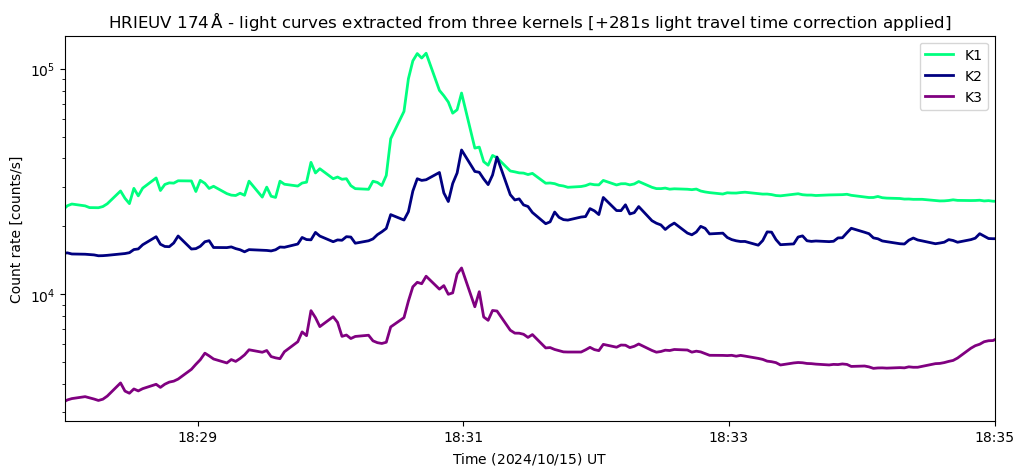

In [13]:
eui_k1 = pd.read_pickle('eui_kernel_1.pkl')
eui_k2 = pd.read_pickle('eui_kernel_2.pkl')
eui_k3 = pd.read_pickle('eui_kernel_3.pkl')

for name,lc in [('K1', eui_k1), ('K2', eui_k2), ('K3', eui_k3)]:
    if 'UTC' in lc:
        lc['UTC'] = pd.to_datetime(lc['UTC']) + pd.Timedelta(seconds=281)
        lc.set_index('UTC', inplace=True)
    else:
        lc.index = pd.to_datetime(lc.index) + pd.Timedelta(seconds=281)
    lc.dropna(inplace=True)

    if name == 'K1':
        eui_k1 = lc
    elif name == 'K2':
        eui_k2 = lc
    elif name == 'K3':
        eui_k3 = lc

plt.figure(figsize=(12,5))
plt.plot(eui_k1.index, eui_k1+2e4, color='springgreen', lw=2, label='K1')
plt.plot(eui_k2.index, eui_k2+1e4, color='navy', lw=2, label='K2')
plt.plot(eui_k3.index, eui_k3, color='purple', lw=2, label='K3')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
plt.yscale('log')
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Count rate [counts/s]')
plt.xlim("2024-10-15T18:28:00", "2024-10-15T18:35:00")
plt.title(r'HRIEUV $174\,\rm\AA$ - light curves extracted from three kernels [+281s light travel time correction applied]')
plt.legend()
plt.show()

### $\color{red}{\text{5. Overview of what we have so far}} $

--- 

#### We show Fermi GBM, STIX, GOES and HRIEUV light curves. We need to decide on

#### which HRIEUV light curve we should use in subsequent analysis.

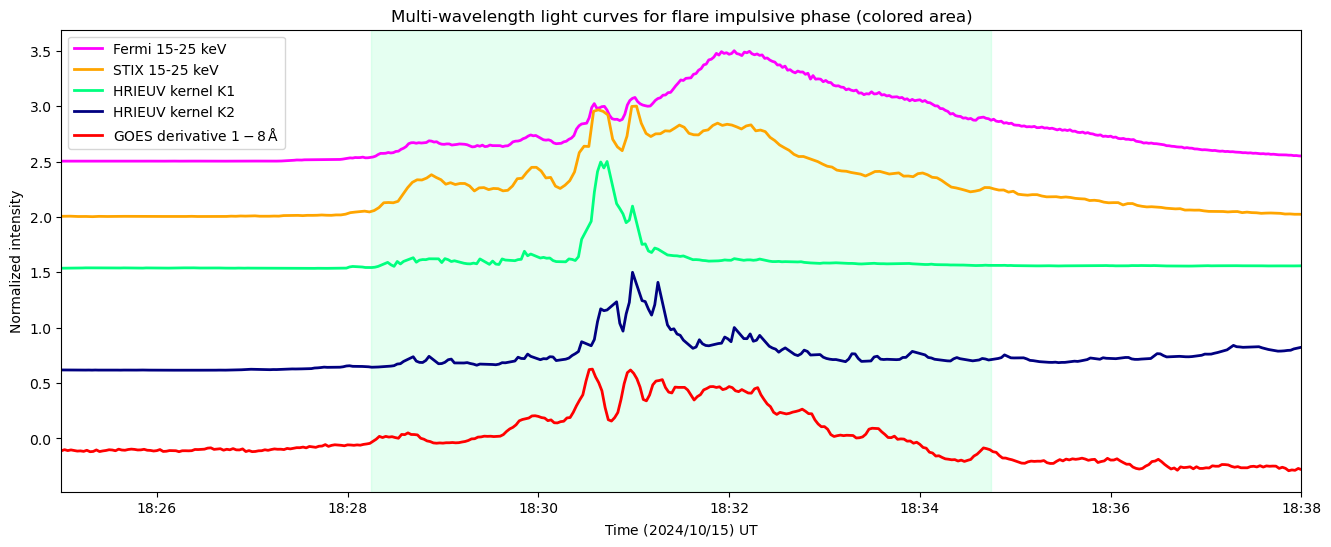

In [14]:
gbm_15_25 = gbm['15-25 keV'].resample('1600ms').mean().dropna()
gbm_15_25 = gbm_15_25 / gbm_15_25.max()
stix_15_25 = stix_15_25 / stix_15_25.max()
eui_k1 = eui_k1 / eui_k1.max()
eui_k2 = eui_k2 / eui_k2.max()

intensity = goes_flare['xrsb'].resample('2s').mean().dropna()
norm_intensity = intensity / intensity.max()
dt = norm_intensity.index.to_series().diff().dt.total_seconds()
dint_dt = norm_intensity.diff()/dt
dint_dt = dint_dt.dropna()
dint_dt_norm = dint_dt / dint_dt.max()
smooth_window = int(12/ 2)  # smoothing
goes = dint_dt_norm.rolling(window=smooth_window, center=True).mean().dropna()

plt.figure(figsize=(16,6))

plt.plot(gbm_15_25.index, gbm_15_25+2.5, color='magenta', label='Fermi 15-25 keV', linewidth=2)
plt.plot(stix_15_25.index, stix_15_25+2, color='orange', label='STIX 15-25 keV', linewidth=2) 
plt.plot(eui_k1.index, eui_k1+1.5, color='springgreen', lw=2, label='HRIEUV kernel K1')
plt.plot(eui_k2.index, eui_k2+0.5, color='navy', lw=2, label='HRIEUV kernel K2')
plt.plot(goes, color='red', label=r'GOES derivative $1-8\,\rm\AA$', linewidth=2)

t1 = pd.to_datetime("2024-10-15T18:28:15")
t2 = pd.to_datetime("2024-10-15T18:34:45")
plt.axvspan(t1, t2, color='springgreen', alpha=0.1)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=2))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.xlim("2024-10-15T18:25:00", "2024-10-15T18:38:00")
plt.title(r'Multi-wavelength light curves for flare impulsive phase (colored area)')
plt.legend()
plt.show()

### $\color{red}{\text{6. Peak detection}} $

--- 

#### We look for peaks in normalized multi-wavelength light curves, in order to

#### determine period of QPPs.

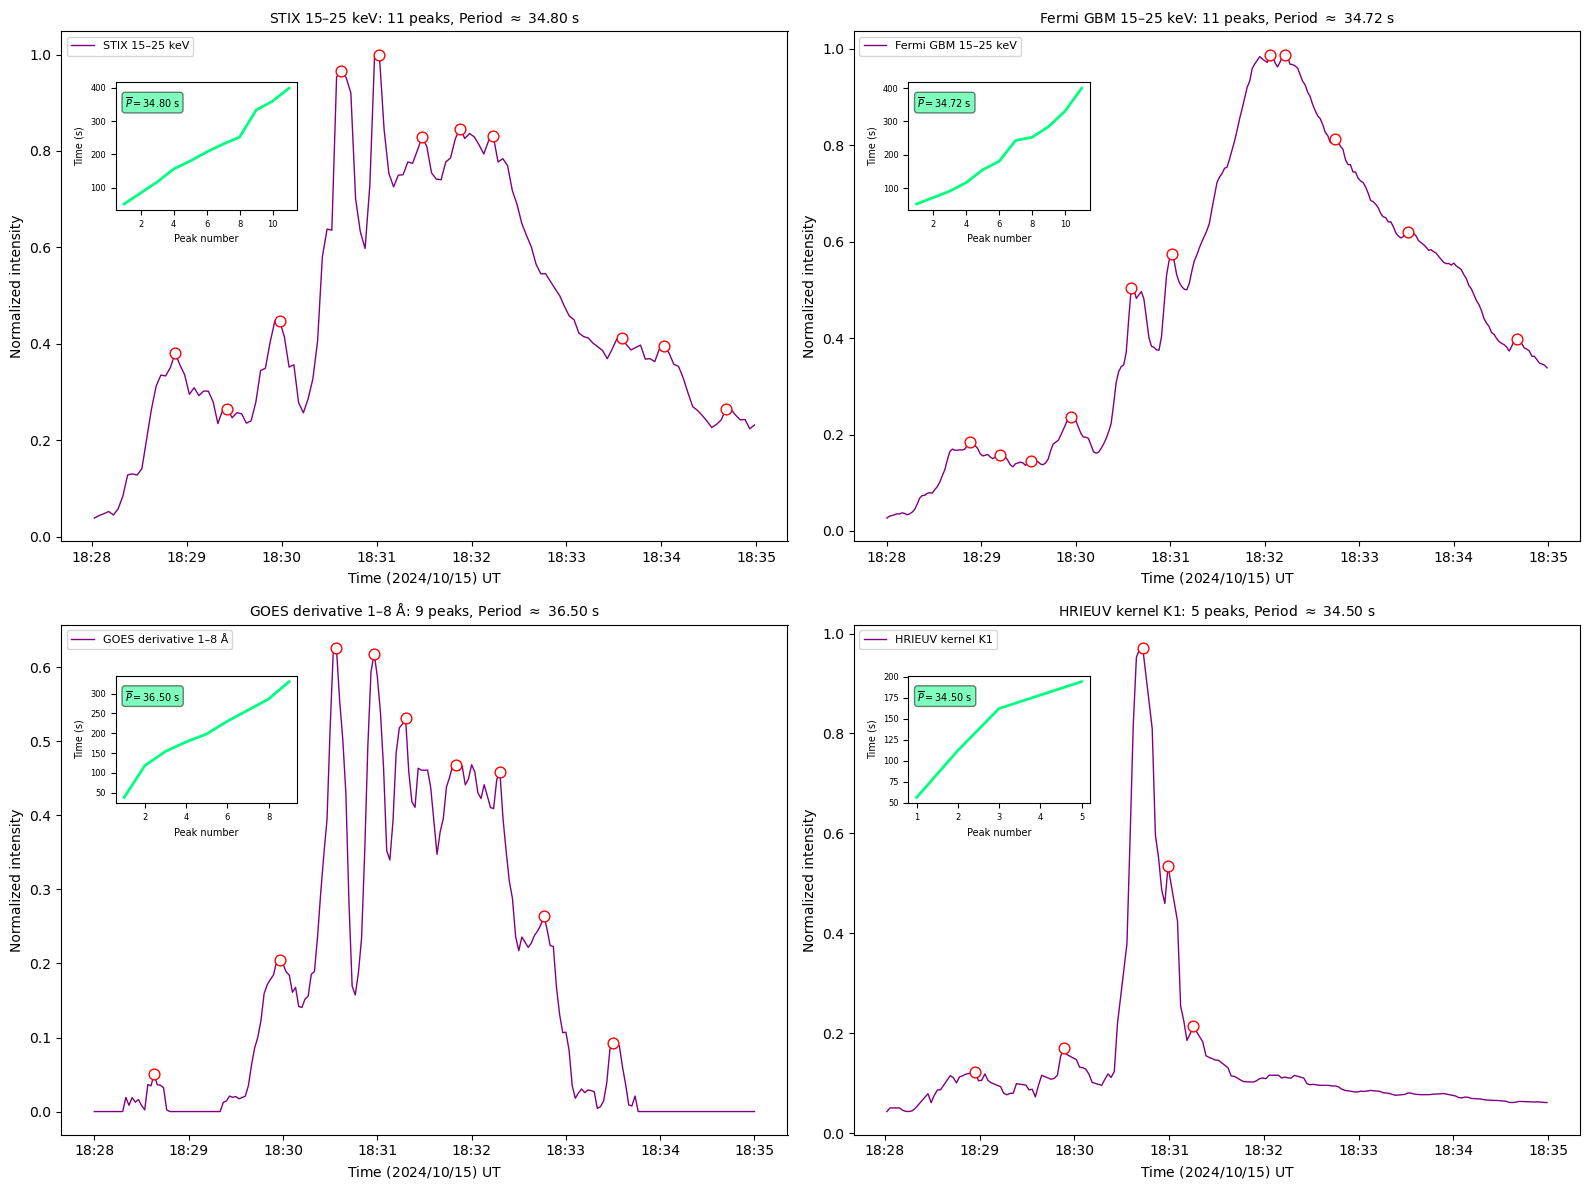

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import find_peaks

def analyze_qpp(lightcurve, label, time_start="2024-10-15T18:28", time_end="2024-10-15T18:35",
                prominence=0.02, distance=3):
 
    if isinstance(time_start, str):
        time_start = pd.to_datetime(time_start, utc=True)
    if isinstance(time_end, str):
        time_end = pd.to_datetime(time_end, utc=True)
    
    if lightcurve.index.tz is None:
        lightcurve.index = lightcurve.index.tz_localize("UTC")
    
    flare_data = lightcurve.truncate(time_start, time_end)
    flare_values = np.array(flare_data.values).astype(float).flatten()
    flare_values = np.maximum(flare_values, 1e-10)  # avoid zeros
    
    time_minutes = (flare_data.index - flare_data.index[0]).total_seconds() / 60
  
    peaks, properties = find_peaks(flare_values, prominence=prominence, distance=distance)
    peak_times = time_minutes[peaks]
    
    period_mins = np.mean(np.diff(peak_times)) if len(peak_times) > 1 else 0
    
    return {
        'flare_data': flare_data,
        'flare_values': flare_values,
        'time_minutes': time_minutes,
        'peaks': peaks,
        'peak_times': peak_times,
        'period_mins': period_mins,
        'label': label}

def plot_qpp_analysis(results, ax):
    flare_data = results['flare_data']
    flare_values = results['flare_values']
    peaks = results['peaks']
    peak_times = results['peak_times']
    period_mins = results['period_mins']
    label = results['label']

    ax.plot(flare_data.index, flare_values, color='purple', linewidth=1, label=label)

    if len(peaks) > 0:
        ax.scatter(flare_data.index[peaks], flare_values[peaks],
                   color='white', s=60, zorder=5, edgecolors='red')
    
    if len(peak_times) > 1:
        inset = ax.inset_axes([0.075, 0.65, 0.25, 0.25])
        peak_times_seconds = peak_times * 60
        avg_period = np.mean(np.diff(peak_times))
        inset.plot(range(1, len(peak_times)+1), peak_times_seconds, color='springgreen', linewidth=2)
        inset.set_xlabel('Peak number', fontsize=7)
        inset.set_ylabel('Time (s)', fontsize=7)
        inset.text(0.05, 0.8, fr'$\overline{{P}}=${60* avg_period :.2f} s',
                   transform=inset.transAxes, fontsize=7,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='springgreen', alpha=0.5))
        inset.tick_params(labelsize=6)
    
    ax.set_xlabel(r'Time $(2024/10/15)$ UT')
    ax.set_ylabel('Normalized intensity')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.legend(fontsize=8, loc='upper left')
    ax.set_title(fr'{label}: {len(peaks)} peaks, Period $\approx$ {period_mins * 60:.2f} s', fontsize=10)

gbm_15_25 = gbm['15-25 keV'].resample('1600ms').mean().dropna()
gbm_15_25 = gbm_15_25 / gbm_15_25.max()
smooth_window = int(4 / 2)  
gbm_15_25 = gbm_15_25.rolling(window=smooth_window, center=True).mean().dropna()
eui_k1 = eui_k1.rolling(window=smooth_window, center=True).mean().dropna()

lightcurves = [
    ("STIX 15–25 keV", stix_15_25, 0.02, 3),
    ("Fermi GBM 15–25 keV", gbm_15_25, 0.005, 5),
    ("GOES derivative 1–8 Å", goes, 0.03, 5),
    ("HRIEUV kernel K1", eui_k1, 0.025, 5)]


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
results_all = []

for i, (label, lc, prom, dist) in enumerate(lightcurves):
    results = analyze_qpp(lc, label, prominence=prom, distance=dist)
    results_all.append(results)
    plot_qpp_analysis(results, axes[i])

plt.tight_layout()
plt.show()

In [ ]:
def plot_results_vertical(results_all):
    n = len(results_all)
    fig, axes = plt.subplots(
        n, 1, figsize=(12, 12), sharex=True,
        gridspec_kw={'hspace': 0})
    if n == 1:
        axes = [axes]

    start = results_all[0]['flare_data'].index[0]
    end   = results_all[0]['flare_data'].index[-1]

    for ax, res in zip(axes, results_all):
        label = res['label']
        flare_data = res['flare_data']
        flare_values = res['flare_values']
        peaks = res['peaks']
        peak_ts = flare_data.index[peaks]

        ax.plot(flare_data.index, flare_values,
                lw=2, color=colors.get(label, "black"), label=label)

        for t in peak_ts:
            ax.axvline(t, color="black", linestyle=":", linewidth=1.5)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
        ax.legend(loc="upper right", fontsize=9)

    axes[-1].set_xlabel("Time (2024/10/15) UT")
    axes[-1].set_xlim(start, end)
    fig.supylabel("Normalized intensity")

    plt.suptitle('Peak finding - period analysis for multi-wavelength light curves')
    plt.tight_layout()
    plt.show()

plot_results_vertical(results_all)

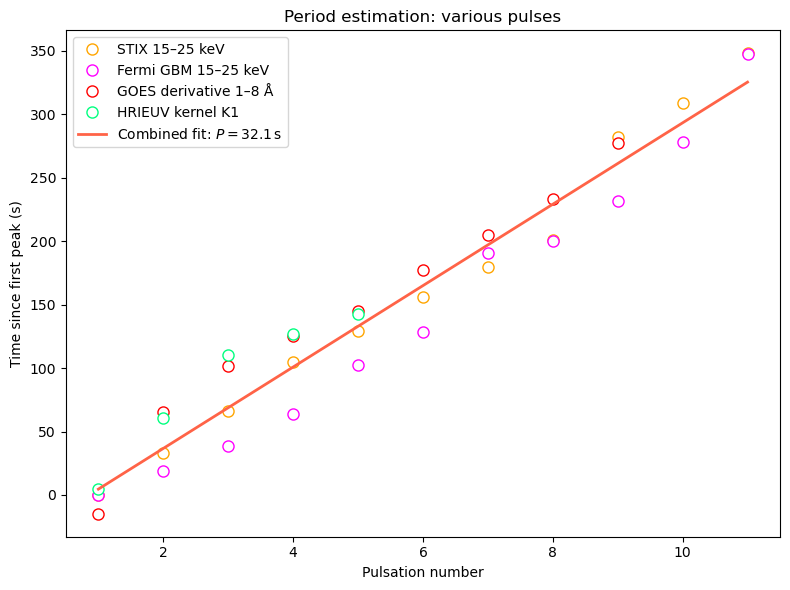

In [636]:
plt.figure(figsize=(8, 6))

all_i, all_t = [], []

for res in results_all:
    label = res['label']
    flare_data = res['flare_data']
    peaks = res['peaks']
    peak_ts = flare_data.index[peaks]
    pulse_num = np.arange(1, len(peak_ts) + 1)
    
    if len(all_t) == 0:
        ref_time = peak_ts[0]
    t_abs = (peak_ts - ref_time).total_seconds()
    color = colors.get(label, "black")
    plt.plot(pulse_num, t_abs, 'o', ms=8,
             mfc='white', mec=color, label=label)

    all_i.append(pulse_num)
    all_t.append(t_abs)

all_i = np.hstack(all_i)
all_t = np.hstack(all_t)
P, t0 = np.polyfit(all_i, all_t, 1)

i_vals = np.arange(1, int(all_i.max()) + 1)
plt.plot(i_vals, P * i_vals + t0,
         '-', lw=2, color='tomato',
         label=rf'Combined fit: $P={P:.1f}\,$s')

plt.xlabel('Pulsation number')
plt.ylabel('Time since first peak (s)')
plt.title('Period estimation: various pulses')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### $\color{red}{\text{7. Wavelet analysis}} $

---

#### Here, we perform detailed wavelet analysis of multi-wavelength light curves. 

In [571]:
def wavelet_analysis(series,
                     dj: float = 0.125,
                     s0_factor: float = 1.0,
                     pad: int = 2,
                     k0: float = 6.0,
                     samples_between_knots: int = 25,
                     detrend: bool = True,
                     detrend_method: str = "spline",
                     period_min = 10.0,
                     period_max = 200.0,
                     peak_method: str = "ridge",
                     min_ratio: float = 1.0,
                     radio: bool = False):
   
    if isinstance(series, pd.DataFrame):
        if series.shape[1] != 1:
            raise ValueError("Input must be a single column")
        y = series.iloc[:, 0].dropna().sort_index()
    else:
        y = series.dropna().sort_index()
    
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("Index must be DateTimeIndex")

    y = y[~y.index.duplicated(keep='first')]
    
    if y.index.tz is not None:
        y.index = y.index.tz_localize(None)

    if radio:
        period_min, period_max = 10.0, 300.0
        min_ratio = max(min_ratio, 1.5)

    t = (y.index - y.index[0]).total_seconds().values
    
    dt_diff = np.diff(t)
    dt_positive = dt_diff[dt_diff > 0]
    if len(dt_positive) == 0:
        raise ValueError("No positive time differences found")
    dt = np.median(dt_positive)
    
    if dt <= 0:
        raise ValueError("Non-positive time step detected.")
    
    N = len(y)
    s0 = s0_factor * dt
    J1 = int(np.log2(N * dt / s0) / dj)

    if detrend:
        if detrend_method == "spline":
            knots = np.arange(samples_between_knots, N, samples_between_knots)
            if len(knots) < 2:
                raise ValueError("Insufficient knot points for spline.")
            spline = LSQUnivariateSpline(t, y.values, t[knots], k=5)
            proc = y.values - spline(t)
        elif detrend_method == "savgol":
            window = int(120.0 / dt)
            if window % 2 == 0:
                window += 1
            window = min(window, N-1)
            if window < 5:
                window = 5
            baseline = savgol_filter(y.values, window_length=window, polyorder=5, mode='interp')
            proc = y.values - baseline
        else:
            raise ValueError("Choose 'spline' or 'savgol' for detrend_method")
        method_label = "Detrended"
    else:
        low, high = 1.0/period_max, 1.0/period_min
        fs = 1.0/dt
        nyq = fs/2.0
        w_low, w_high = low/nyq, high/nyq
        if 0 < w_low < w_high < 1:
            b, a = butter(2, [w_low, w_high], btype='bandpass')
            proc = filtfilt(b, a, y.values)
        else:
            proc = y.values.copy()
        method_label = "Bandpass Filtered"

    norm_det = proc / np.max(np.abs(proc))

    wave, period, scale, coi = wavelet(proc, dt, pad=pad, dj=dj,
                                      s0=s0, J1=J1, mother='MORLET', param=k0)
    power = np.abs(wave)**2

    var = np.var(proc, ddof=1)
    lag1 = np.corrcoef(proc[:-1], proc[1:])[0,1]
    sig_local = wave_signif(var, dt, scale, sigtest=0, lag1=lag1, mother='MORLET')
    sig_global = wave_signif(var, dt, scale, sigtest=1, lag1=lag1,
                             dof=np.maximum(1, N-scale), mother='MORLET')

    band = (period>=period_min)&(period<=period_max)
    global_ws = power.mean(axis=1)
    mask = band & (global_ws>sig_local*min_ratio)
    labeled, nregions = nd_label(mask)
    if nregions==0:
        raise ValueError(f"No significant QPP in {period_min}-{period_max}s band")
    best_period = None
    if peak_method=="ridge":
        best_len=-1
        for idx in np.where(mask)[0]:
            length=np.sum(power[idx]>sig_local[idx])
            if length>best_len:
                best_len,length, best_period = length,length,period[idx]
    elif peak_method=="ratio_ridge":
        best_score=-np.inf
        for idx in np.where(mask)[0]:
            ratio=global_ws[idx]/sig_local[idx]
            if ratio<min_ratio: continue
            length=np.sum(power[idx]>sig_local[idx])
            score=ratio*length
            if score>best_score:
                best_score, best_period=score,period[idx]
    else:
        raise ValueError("peak_method must be 'ridge' or 'ratio_ridge'")
    if best_period is None:
        raise ValueError("No period selected")
    sel=(period>=(best_period*(1-dj)))&(period<=(best_period*(1+dj)))&mask
    left=period[sel].min() if sel.any() else best_period
    right=period[sel].max() if sel.any() else best_period
    err_low=best_period-left
    err_high=right-best_period

    fig=plt.figure(figsize=(12,8))
    gs=fig.add_gridspec(2,4,height_ratios=[2,3],width_ratios=[1,1,1,1],
                        hspace=0.1,wspace=0.2)

    ax_ts=fig.add_subplot(gs[0,:3])
    ax_ts.plot(t,norm_det,'k',lw=1)
    ax_ts.set_xlim(t.min(),t.max())
    ax_ts.set_ylim((-1, 1) if detrend else (norm_det.min(), norm_det.max()))
    ax_ts.set_ylabel('Normalized Intensity')
    ax_ts.set_title(r'')
    ax_ts.xaxis.set_visible(False)
 
    ax_box=fig.add_subplot(gs[0,3])
    ax_box.axis('off')
    ax_box.text(0.5,0.5,rf"$P={best_period:.1f}^{{+{err_high:.1f}}}_{{-{err_low:.1f}}}\,s$",
                ha='center',va='center',transform=ax_box.transAxes,
                fontsize=12,bbox=dict(boxstyle='round,pad=0.3',edgecolor='red',
                                     facecolor='indianred',alpha=0.3,linewidth=2))

    ax_wps = fig.add_subplot(gs[1,:3])
    ax_wps.set_facecolor('black')
    T,Pm = np.meshgrid(t,period)
    ax_wps.contourf(T,Pm,power,levels=10,cmap='viridis',extend='both')
    ax_wps.contour(T,Pm,power/sig_local[:,None],levels=[1],colors='orange',linewidths=1)
    ax_wps.plot(t,coi,'w-',lw=1.5)
    ax_wps.fill_between(t,coi,period.max(),facecolor='none',edgecolor='white',alpha=0.3)
    ax_wps.axhline(best_period,color='white',ls='--',lw=1)
    ax_wps.set_xlabel("Time (s)")
    ax_wps.set_ylabel("Period (s)")
    ax_wps.set_yscale('log')
    ymin=period.min()
    ymax=period.max()
    ax_wps.set_ylim(ymin,ymax)
    yticks=[ymin,100,ymax]
    ax_wps.set_yticks(yticks)
    ax_wps.set_xlim(t.min(),t.max())

    ax_gws=fig.add_subplot(gs[1,3],sharey=ax_wps)
    norm_ws=global_ws/np.nanmax(global_ws)
    norm_sig=(sig_local if period_min is not None else sig_global)/np.nanmax(global_ws)
    ax_gws.plot(norm_ws,period,'k')
    ax_gws.plot(norm_sig,period,'k--', label=r'$95\%$ significance')
    ax_gws.axhline(best_period,color='red',ls='--',lw=1)
    ax_gws.set_xscale('log')
    ax_gws.set_xlim(0.001,1)
    ax_gws.set_xlabel("Normalized Power")
    ax_gws.yaxis.set_visible(False)
    ax_gws.set_title('Global spectrum')
    ax_gws.legend()

    return best_period, err_low, err_high, fig

--- 

#### Fermi GBM ($15-25\,\rm keV$):

#### - wavelet analysis with detrending

---

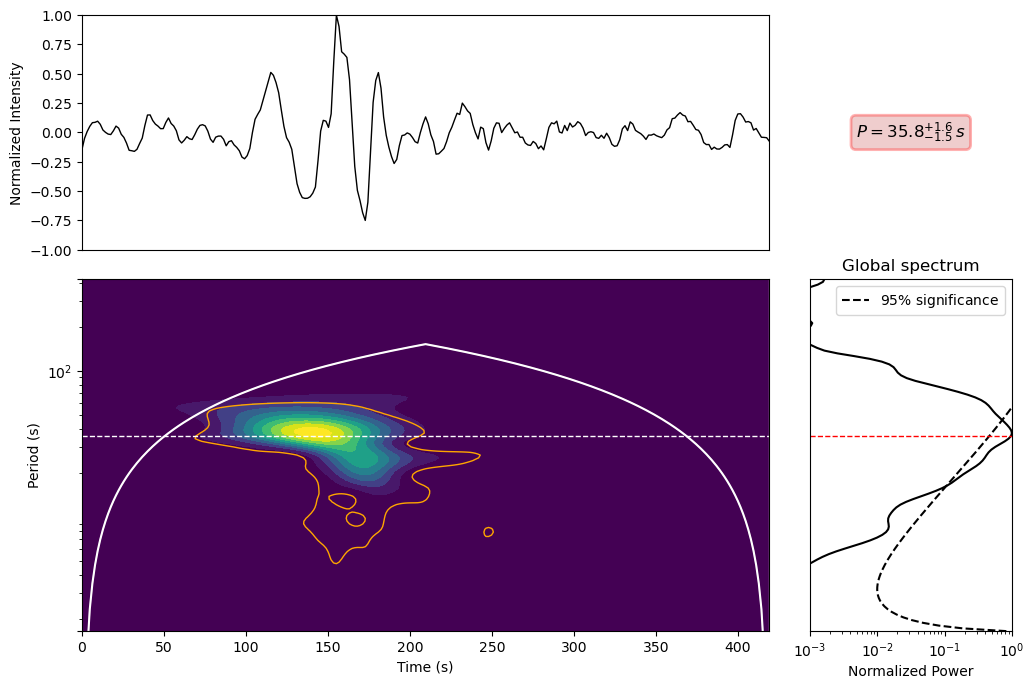

In [671]:
start = pd.to_datetime("2024-10-15T18:28:00", utc=True)
end = pd.to_datetime("2024-10-15T18:35:00", utc=True)

gbm_15_25 = gbm_15_25.truncate(start, end)
P0, err_low, err_high, fig = wavelet_analysis(gbm_15_25, dj=0.0625,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

--- 

#### STIX ($15-25\,\rm keV$):

#### - wavelet analysis with detrending

---

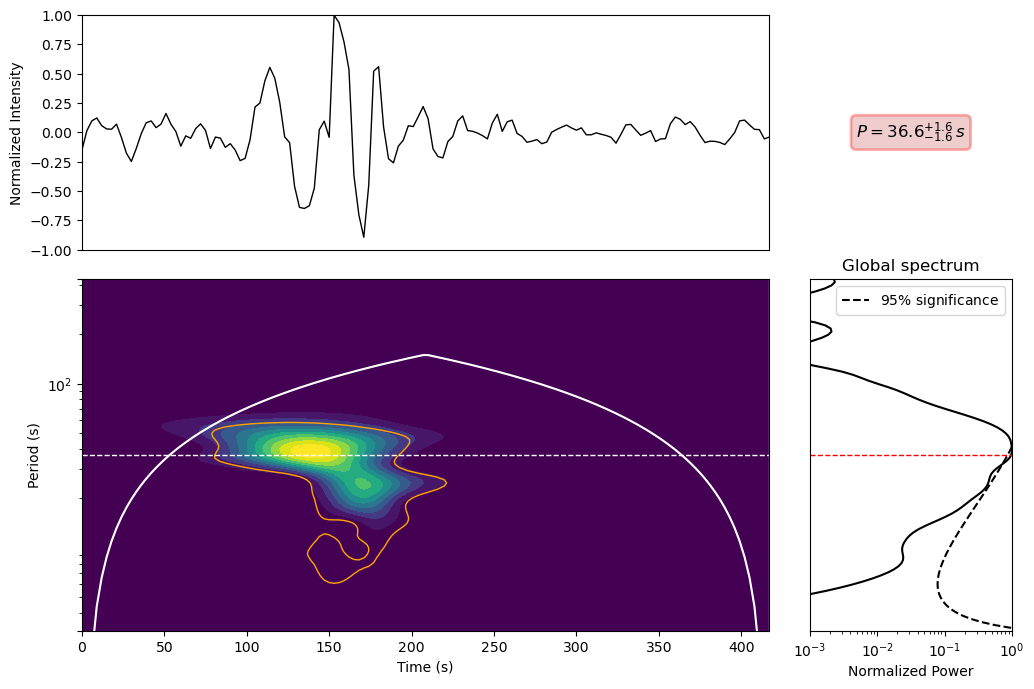

In [401]:
stix_15_25 = stix_15_25.truncate(start, end)
P0, err_low, err_high, fig = wavelet_analysis(stix_15_25, dj=0.0625,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

--- 

#### GOES derivative ($1-8\,\rm Å$):

#### - wavelet analysis with detrending

---

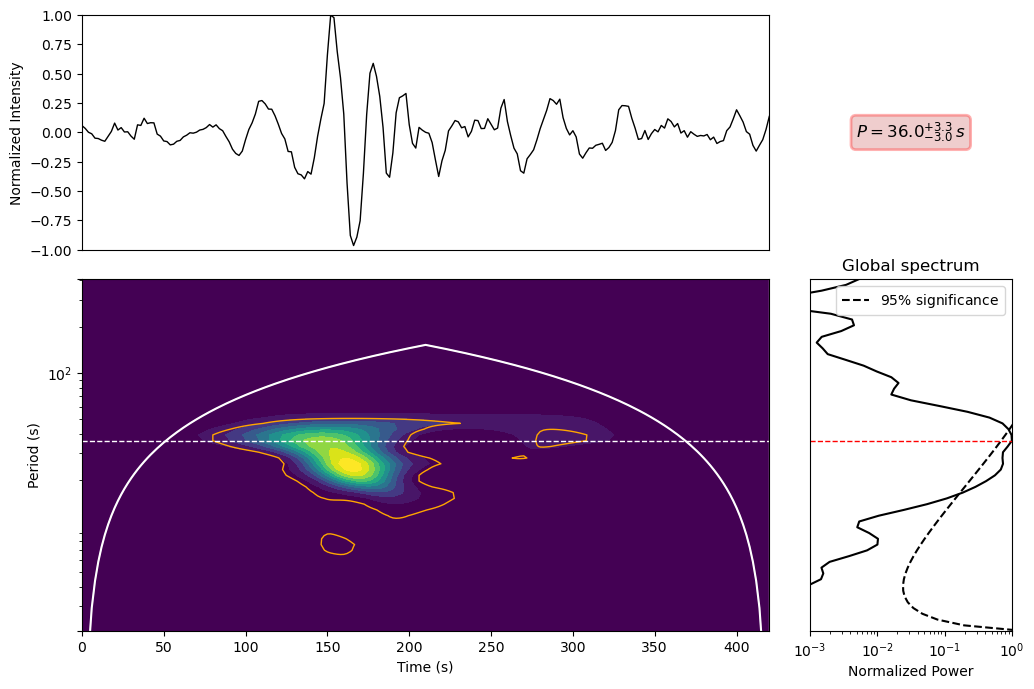

In [433]:
goes = goes.truncate(start,end)
P0, err_low, err_high, fig = wavelet_analysis(goes, dj=0.125,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

--- 

#### HRIEUV ($174\,\rm Å$), all three kernels:

#### - wavelet analysis with detrending

#### - kernel K1 (upper)

#### - kernel K2 (middle)

#### - kernel K3 (lower)
---

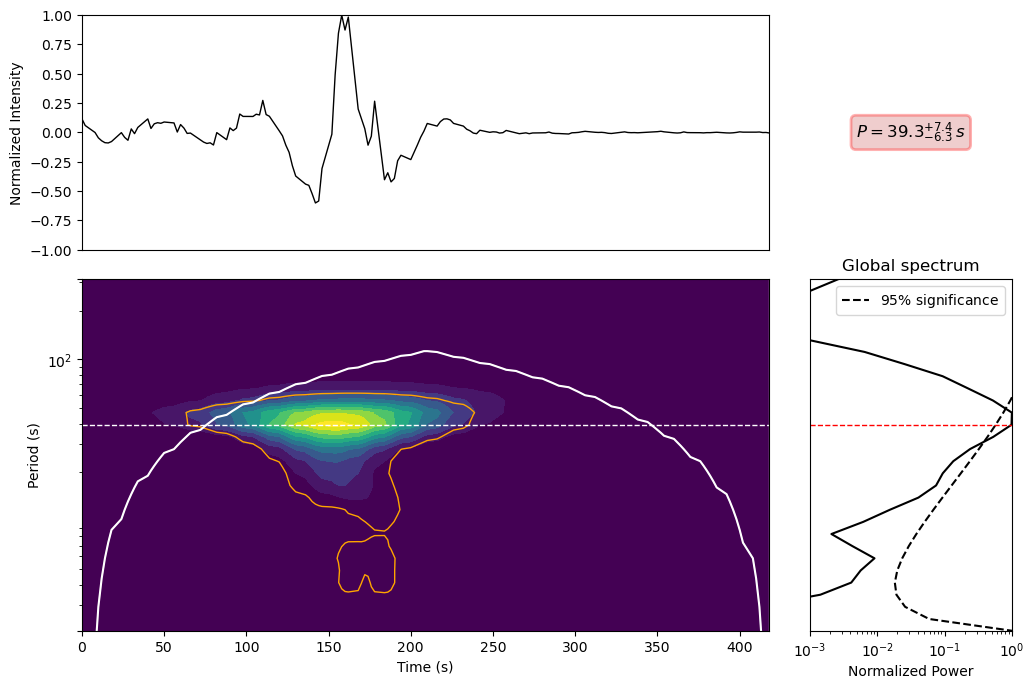

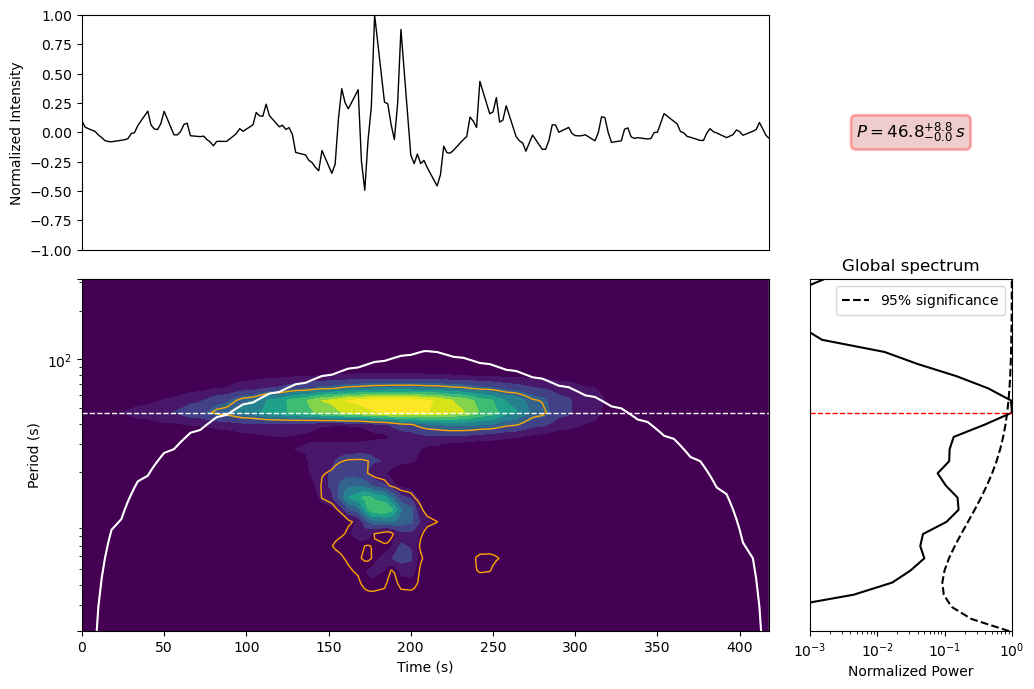

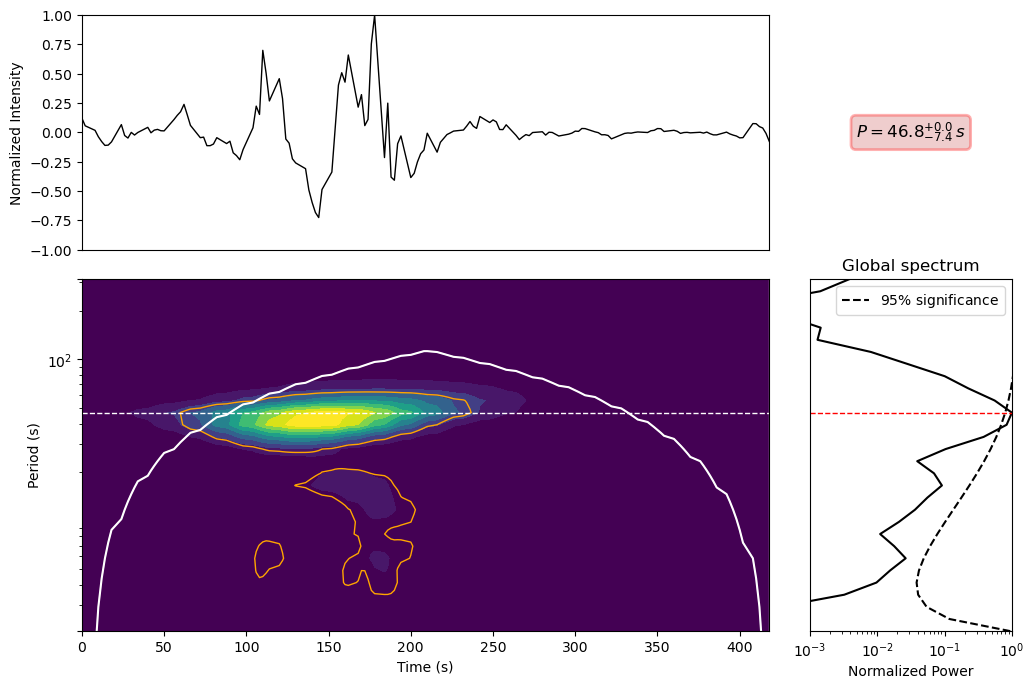

In [640]:
# we import these light curves again!!!

eui_k1 = pd.read_pickle('eui_kernel_1.pkl')
eui_k2 = pd.read_pickle('eui_kernel_2.pkl')
eui_k3 = pd.read_pickle('eui_kernel_3.pkl')

# we perform time correction!!!

for name,lc in [('K1', eui_k1), ('K2', eui_k2), ('K3', eui_k3)]:
    if 'UTC' in lc:
        lc['UTC'] = pd.to_datetime(lc['UTC']) + pd.Timedelta(seconds=281)
        lc.set_index('UTC', inplace=True)
    else:
        lc.index = pd.to_datetime(lc.index) + pd.Timedelta(seconds=281)
    lc.dropna(inplace=True)

    if name == 'K1':
        eui_k1 = lc
    elif name == 'K2':
        eui_k2 = lc
    elif name == 'K3':
        eui_k3 = lc

eui_k1, eui_k2, eui_k3 = eui_k1 / eui_k1.max(), eui_k2 / eui_k2.max(), eui_k3 / eui_k3.max(), 

smooth_window = int(3/2) # smoothing
eui_k1 = eui_k1.rolling(window=smooth_window, center=True).mean().dropna()
eui_k2 = eui_k2.rolling(window=smooth_window, center=True).mean().dropna()
eui_k3 = eui_k3.rolling(window=smooth_window, center=True).mean().dropna()

start = pd.to_datetime("2024-10-15T18:28:00")
end = pd.to_datetime("2024-10-15T18:35:00")

eui_k1 = eui_k1.truncate(start, end)
eui_k2 = eui_k2.truncate(start, end)
eui_k3 = eui_k3.truncate(start, end)

P0, err_low, err_high, fig = wavelet_analysis(eui_k1, dj=0.25,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

P0, err_low, err_high, fig = wavelet_analysis(eui_k2, dj=0.125,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

P0, err_low, err_high, fig = wavelet_analysis(eui_k3, dj=0.125,
                            detrend=True, peak_method='ratio_ridge', 
                            detrend_method='savgol')

---

#### Below, since it's appropriate now, for comparison, we give the periods found in different light curves via 

#### wavelet analysis:

| $\lambda$ | (S) $15-25\,\rm keV$ | (F) $15–25\,\rm keV$ | $174\,\rm Å$ | $1–8\,\rm Å$ |
|----|--------:|----------|--------|-------|
| Period (s) | $36.6^{+1.6}_{−1.6}$ | $35.8^{+1.6}_{−1.5}$ | $39.3^{7.4}_{−6.3}$ | $36.6^{+3.3}_{−3.0}$ |